# Fair targeting under a budget, from treatment-effect estimates

**Question.** A programme ran a randomised trial of an intervention (think: SMS reminder + small incentive for child immunisation). The trial shows it works on average. Now the programme can only afford to treat 30% of the population. *Who should get it, and what does it cost to guarantee rural households a fair share?*

**Pipeline.**
1. Simulate a population with a *known* heterogeneous treatment effect (CATE), so every rule can be scored against the oracle.
2. Draw an RCT from it and estimate the CATE with cross-fitted T- and DR-learners (scikit-learn only).
3. Allocate a fixed budget: uniform (the RCT's own rule), greedy on estimated CATE, and greedy with per-group budget floors (an LP whose relaxation is integral).
4. Decompose the welfare loss into *estimation error* and *price of fairness*, with bootstrap CIs.

All code lives in the `fairtarget` package; this notebook just drives it.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fairtarget import *

GROUP_NAMES = {0: "urban", 1: "rural"}
N, BUDGET, SEED = 10_000, 0.30, 0
pop = simulate_population(n=N, seed=SEED)
trial = draw_trial(pop, seed=SEED + 1)
X, W, Y = trial[COVARIATES], trial["W"].values, trial["Y"].values
k = int(BUDGET * N)
trial.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
rural,0.40,0.49,0.0,1.00
log_income,8.08,0.63,6.0,10.37
distance_km,6.13,6.66,0.0,61.85
mother_edu,8.09,3.41,0.0,16.00
prior_visit,0.55,0.50,0.0,1.00
W,0.50,0.50,0.0,1.00
Y,0.53,0.50,0.0,1.00


## 1. What the ground truth looks like

Rural households sit further from clinics. The intervention's effect is an inverted-U in distance: near households attend anyway, remote ones face a travel constraint a nudge cannot remove. So the *true* effect is on average smaller for rural households, and an allocator that chases effect size alone will under-serve them.

Mean true CATE  urban=0.158  rural=0.117


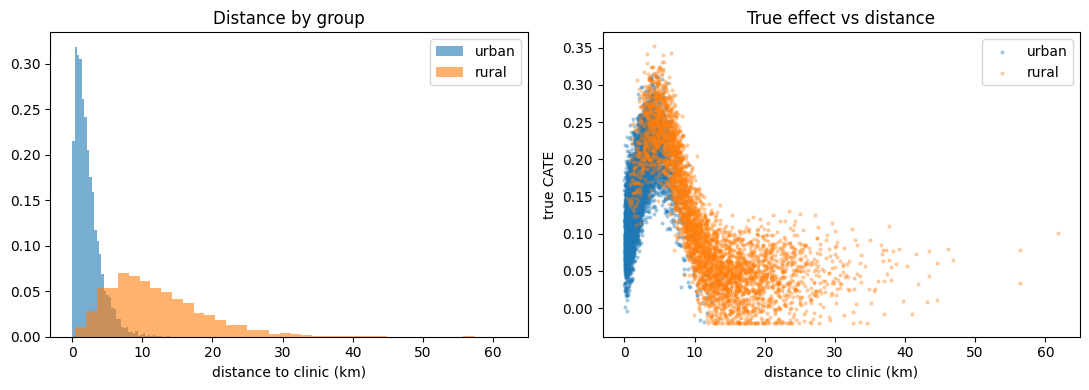

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for g, name in GROUP_NAMES.items():
    m = pop.group == g
    axes[0].hist(pop.X.distance_km[m], bins=40, alpha=.6, label=name, density=True)
    axes[1].scatter(pop.X.distance_km[m], pop.tau[m], s=4, alpha=.3, label=name)
axes[0].set(xlabel="distance to clinic (km)", title="Distance by group"); axes[0].legend()
axes[1].set(xlabel="distance to clinic (km)", ylabel="true CATE", title="True effect vs distance"); axes[1].legend()
plt.tight_layout()
print(f"Mean true CATE  urban={pop.tau[pop.group==0].mean():.3f}  rural={pop.tau[pop.group==1].mean():.3f}")

## 2. Estimate the CATE from the trial

Out-of-fold predictions only: we rank people on these, so in-sample fits would be optimistic.

T-learner   RMSE=0.0683  corr=0.615  mean est: urban=0.153 rural=0.103
DR-learner  RMSE=0.0655  corr=0.597  mean est: urban=0.151 rural=0.106


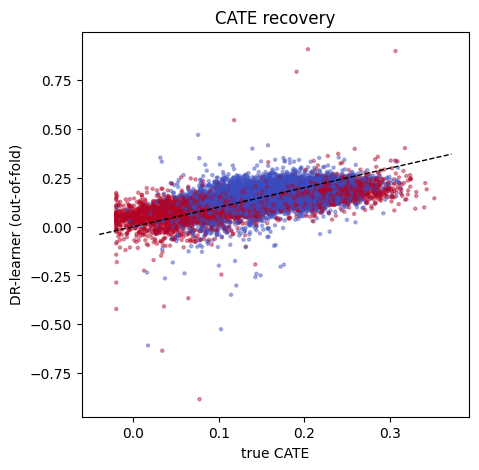

In [3]:
tau_t  = crossfit_cate(TLearner,  X, W, Y, seed=SEED)
tau_dr = crossfit_cate(DRLearner, X, W, Y, seed=SEED)
for name, est in [("T-learner", tau_t), ("DR-learner", tau_dr)]:
    rmse = np.sqrt(np.mean((est - pop.tau)**2)); corr = np.corrcoef(est, pop.tau)[0,1]
    print(f"{name:11s} RMSE={rmse:.4f}  corr={corr:.3f}  "
          f"mean est: urban={est[pop.group==0].mean():.3f} rural={est[pop.group==1].mean():.3f}")
plt.figure(figsize=(5,5))
plt.scatter(pop.tau, tau_dr, s=5, alpha=.4, c=pop.group, cmap="coolwarm")
lim=[pop.tau.min()-.02, pop.tau.max()+.02]; plt.plot(lim, lim, "k--", lw=1)
plt.xlabel("true CATE"); plt.ylabel("DR-learner (out-of-fold)"); plt.title("CATE recovery");

## 3. Allocate the budget

`fair_floor` solves  max Σ sᵢaᵢ  s.t. Σaᵢ ≤ k, Σ_{i∈g} aᵢ ≥ floor_g·k. The constraint matrix is totally unimodular, so the LP returns a 0/1 allocation directly.

In [4]:
rural_share = pop.group.mean()
allocs = {
    "uniform (RCT rule)":   uniform(N, k, SEED),
    "greedy T-learner":     greedy(tau_t, k),
    "greedy DR-learner":    greedy(tau_dr, k),
    f"DR + rural floor {rural_share:.0%}": fair_floor(tau_dr, pop.group, k, {1: rural_share}),
    "DR + rural floor 60%": fair_floor(tau_dr, pop.group, k, {1: 0.60}),
    "oracle (true CATE)":   greedy(pop.tau, k),
}
table = summarise(allocs, pop.tau, pop.group, GROUP_NAMES)
cis = {r: bootstrap_gain(a, pop.tau, seed=SEED) for r, a in allocs.items()}
table["ci_low"]  = [cis[r][1] for r in table.index]
table["ci_high"] = [cis[r][2] for r in table.index]
table.round(3)

,treated,expected_gain,share_of_oracle,coverage_urban,coverage_rural,benefit_share_urban,benefit_share_rural,ci_low,ci_high
rule,,,,,,,,,
uniform (RCT rule),3000,426.601,0.631,0.308,0.288,0.689,0.311,411.280,442.531
greedy T-learner,3000,579.308,0.857,0.358,0.213,0.683,0.317,561.212,596.848
greedy DR-learner,3000,579.181,0.857,0.371,0.193,0.703,0.297,561.213,596.527
DR + rural floor 40%,3000,583.432,0.864,0.300,0.300,0.572,0.428,565.719,599.403
DR + rural floor 60%,3000,554.244,0.820,0.199,0.452,0.407,0.593,538.067,569.838
oracle (true CATE),3000,675.603,1.000,0.319,0.272,0.618,0.382,655.160,695.398


## 4. Decompose the loss

- **oracle − greedy(estimated)**: cost of estimation error.
- **greedy(estimated) − fair(estimated)**: price of fairness.

Note what happens at the *proportional* floor: it is roughly free, or even slightly positive. The estimators under-shoot rural effects relative to the oracle, so forcing proportional coverage pulls the allocation back toward what a perfect estimator would do. Fairness constraints can act as a regulariser against estimation bias; that is a point worth making to any programme manager who sees equity and efficiency as a pure trade-off.

Oracle gain                         675.6
  - estimation error                 96.4  (14.3% of oracle)
  - price of proportional floor      -4.3  (-0.6% of oracle)
Uniform (RCT) gain                  426.6


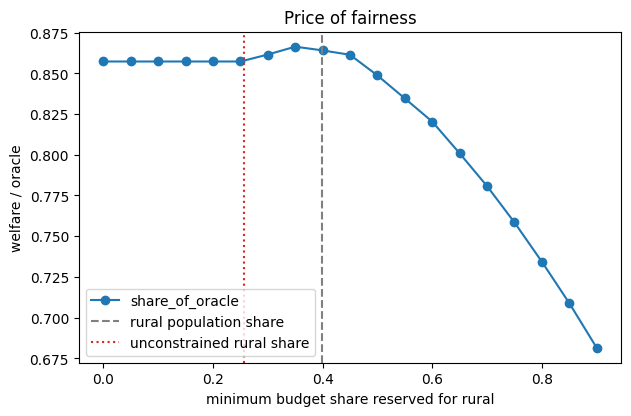

In [5]:
o, g, f = (table.expected_gain[r] for r in ["oracle (true CATE)", "greedy DR-learner", f"DR + rural floor {rural_share:.0%}"])
print(f"Oracle gain                       {o:7.1f}")
print(f"  - estimation error              {o-g:7.1f}  ({(o-g)/o:.1%} of oracle)")
print(f"  - price of proportional floor   {g-f:7.1f}  ({(g-f)/o:+.1%} of oracle)")
print(f"Uniform (RCT) gain                {table.expected_gain['uniform (RCT rule)']:7.1f}")

floors = np.linspace(0, .9, 19); curve = []
for fl in floors:
    try: a = fair_floor(tau_dr, pop.group, k, {1: fl})
    except ValueError: break
    curve.append((fl, welfare(a, pop.tau)/o, a[pop.group==1].mean()))
curve = pd.DataFrame(curve, columns=["rural_floor","share_of_oracle","rural_coverage"])
ax = curve.plot(x="rural_floor", y="share_of_oracle", marker="o", legend=False, figsize=(7,4.3))
ax.axvline(rural_share, ls="--", c="grey", label="rural population share")
ax.axvline(allocs["greedy DR-learner"][pop.group==1].sum()/k, ls=":", c="C3", label="unconstrained rural share")
ax.set(xlabel="minimum budget share reserved for rural", ylabel="welfare / oracle", title="Price of fairness"); ax.legend();

## 5. How much does targeting buy, across budgets?

budget,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60
targeting lift over uniform,0.46,0.39,0.41,0.38,0.37,0.36,0.35,0.33,0.3,0.28,0.25,0.24


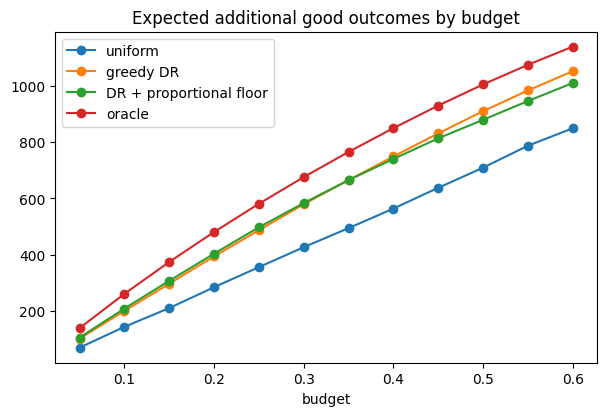

In [6]:
rows = []
for fr in np.linspace(.05, .6, 12):
    kk = int(fr*N)
    rows.append({"budget": fr,
        "uniform": welfare(uniform(N, kk, SEED), pop.tau),
        "greedy DR": welfare(greedy(tau_dr, kk), pop.tau),
        "DR + proportional floor": welfare(fair_floor(tau_dr, pop.group, kk, {1: rural_share}), pop.tau),
        "oracle": welfare(greedy(pop.tau, kk), pop.tau)})
sweep = pd.DataFrame(rows).set_index("budget")
sweep.plot(marker="o", figsize=(7,4.3), title="Expected additional good outcomes by budget");
(sweep["greedy DR"]/sweep["uniform"]-1).round(2).rename("targeting lift over uniform").to_frame().T